Q2. In a simple 4x4 grid world, an agent must learn to reach a goal from a starting point while
avoiding a single obstacle. Use the SARSA algorithm to find the optimal path.
Requirements:
> Implement a grid world environment with one obstacle and a goal state.

> Use the SARSA algorithm to teach the agent to avoid the obstacle and reach the goal.

> Experiment with different ε-greedy policies for exploration.

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

Implement a grid world environment with one obstacle and a goal state.

In [ ]:
# Grid
size = 4
start = (0, 0)
goal = (3, 3)
obstacle = (1, 1)

# actions and moves:
actions = ['up', 'down', 'left', 'right']
moves = {
  'up': (-1, 0), 'down': (1, 0), 'left': (0, -1), 'right': (0, 1)
}

In [ ]:
# move the agent:
def step(state, action):
  move = moves[action]
  next_state = (state[0] + move[0], state[1] + move[1])

  # outside the grid:
  if next_state[0] < 0 or next_state[0] >= size or next_state[1] < 0 or next_state[1] >= size:
    return (state, -5, False)

  # obstacle:
  if next_state == obstacle:
    return (next_state, -20, True)

  # goal:
  if next_state == goal:
    return (next_state, 50, True)

  # normal movement:
  return (next_state, -1, False)

In [ ]:
# choose action:
def choose_action(Q, state, epsilon):
  # explore:
  if random.random() < epsilon:
    return random.choice(actions)

  # exploit:
  row, col = state
  return actions[np.argmax(Q[row, col])]

Use the SARSA algorithm to teach the agent to avoid the obstacle and reach the
goal.

In [ ]:
# SARSA training:
def train_sarsa(epsilon):

  Q = np.zeros((size, size, len(actions)))
  alpha = 0.1
  gamma = 0.9
  rewards = []

  for episode in range(1000):
    state = start
    action = choose_action(Q, state, epsilon)
    total_reward = 0

    for i in range(100):
      # take action:
      next_state, reward, done = step(state, action)

      # choose next action:
      next_action = choose_action(Q, next_state, epsilon)

      # state and action index:
      r, c = state
      action_index = actions.index(action)
      nr , nc = next_state
      next_action_index = actions.index(next_action)

      # SARSA update:
      Q[r, c, action_index] = ((Q[r,c,action_index]) + (alpha*(reward+gamma * Q[nr,nc,next_action_index] - Q[r,c,action_index])))

      # move to the next state:
      state = next_state
      action = next_action
      total_reward += reward
      if done:
        break
    rewards.append(total_reward)
  return Q, rewards

Experiment with different ε-greedy policies for exploration.

In [ ]:
# try different epsilon values:
epsilons = [1.0, 0.5,0.75, 0.1]
results = {}

for epsilon in epsilons:
  Q, rewards = train_sarsa(epsilon)
  results[epsilon] = (Q, rewards)

  print("Epsilon =", epsilon, ", Average Reward =", np.mean(rewards[-50:]))

Epsilon = 1.0 , Average Reward = -40.24
Epsilon = 0.5 , Average Reward = 15.58
Epsilon = 0.75 , Average Reward = -9.66
Epsilon = 0.1 , Average Reward = 39.9


In [ ]:
# find the learned path:
def get_path(Q):
  state = start
  path = [start]
  for i in range(100):
    row, col = state

    # best action is:
    action = actions[np.argmax(Q[row, col])]
    next_state, reward, done = step(state, action)

    # stop when action present outside or obstacle:
    if next_state in path or next_state == obstacle:
      break
    path.append(next_state)
    state = next_state
    if done:
      break
  return path

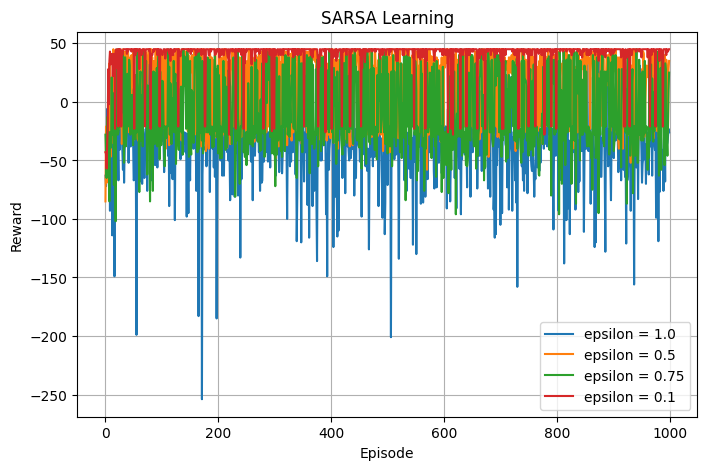

In [ ]:
# plot learning:
plt.figure(figsize=(8, 5))
for epsilon in epsilons:
  Q, rewards = results[epsilon]
  plt.plot(rewards, label="epsilon = " + str(epsilon))
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("SARSA Learning")
plt.legend()
plt.grid()
plt.show()

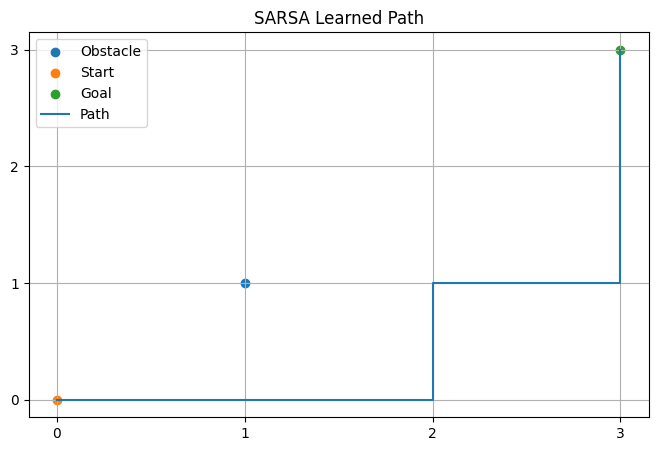

In [ ]:
# final path:
Q, rewards = results[0.1]
path = get_path(Q)
plt.figure(figsize=(8, 5))

# draw obstacle:
plt.scatter(obstacle[1], obstacle[0], label="Obstacle")
# draw start:
plt.scatter(start[1], start[0], label="Start")
# draw goal:
plt.scatter(goal[1], goal[0], label="Goal")

# draw path:
rows = [p[0] for p in path]
cols = [p[1] for p in path]
plt.plot(cols, rows, label="Path")

# grid:
plt.xticks(range(size))
plt.yticks(range(size))
plt.grid()
plt.legend()
plt.title("SARSA Learned Path")
plt.show()